# Polymarket Data Exploration

Explore live prediction market data from Polymarket's public API.

**No database or API keys required** - all data fetched directly from Polymarket.

See `API_GUIDE.md` in this folder for detailed documentation.

---

## What You'll Learn

1. **Fetch live markets** - Current prediction markets with real-time prices
2. **Understand the data** - What each field means and how to interpret it
3. **Visualize markets** - Dashboard showing price distributions and volume
4. **Order books** - See actual bid/ask liquidity
5. **Sports markets** - Find NBA and other sports predictions

## 1. Setup & Imports

In [96]:
# Core imports
from cuic_quant.notebook import pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import json
from datetime import datetime

# Display settings for better output
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 150)
pd.set_option('display.max_rows', 25)

print("Setup complete!")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Setup complete!
Timestamp: 2026-02-04 23:03:54


---

## 2. Fetch Live Markets

We'll fetch **currently open** markets directly from the Polymarket API.

Key parameters:
- `closed=false` - Only markets still open for trading
- `active=true` - Markets that are actively accepting orders

In [97]:
# Fetch LIVE open markets directly from the API
response = requests.get(
    "https://gamma-api.polymarket.com/markets",
    params={
        "limit": 100,
        "closed": "false",   # Only open markets
        "active": "true"     # Only active markets
    }
)

raw_markets = response.json()
print(f"Fetched {len(raw_markets)} live markets from Polymarket API")
print(f"API Status: {response.status_code}")

Fetched 100 live markets from Polymarket API
API Status: 200


---

## 3. Understanding the Raw Data

Let's look at what fields we get from the API and what they mean.

In [ ]:
# Look at one market in detail
if raw_markets:
    example = raw_markets[0]

    print("EXAMPLE MARKET - RAW DATA")
    print("=" * 60)
    print(f"Question: {example.get('question', 'N/A')}")
    print()

    # Key fields explained
    key_fields = [
        ('id', 'Unique market identifier'),
        ('question', 'What the market is predicting'),
        ('outcomePrices', 'Current YES/NO prices (JSON string)'),
        ('volume', 'Total USD traded on this market'),
        ('volume24hr', 'USD traded in last 24 hours'),
        ('liquidity', 'Current liquidity available'),
        ('bestBid', 'Highest buy order price'),
        ('bestAsk', 'Lowest sell order price'),
        ('spread', 'Gap between bid and ask'),
        ('endDate', 'When the market resolves'),
        ('clobTokenIds', 'Token IDs for orderbook queries'),
    ]

    print("KEY FIELDS:")
    print("-" * 60)
    for field, description in key_fields:
        value = example.get(field, 'N/A')
        # Truncate long values
        if isinstance(value, str) and len(value) > 50:
            value = value[:50] + '...'
        print(f"{field:20} = {value}")
        print(f"{'':20}   ^ {description}")
        print()

EXAMPLE MARKET - RAW DATA
Question: Will Trump deport less than 250,000?

KEY FIELDS:
------------------------------------------------------------
id                   = 517310
                       ^ Unique market identifier

question             = Will Trump deport less than 250,000?
                       ^ What the market is predicting

outcomePrices        = ["0.0405", "0.9595"]
                       ^ Current YES/NO prices (JSON string)

volume               = 1046884.28145
                       ^ Total USD traded on this market

volume24hr           = 6621.461408999992
                       ^ USD traded in last 24 hours

liquidity            = 15190.13299
                       ^ Current liquidity available

bestBid              = 0.04
                       ^ Highest buy order price

bestAsk              = 0.041
                       ^ Lowest sell order price

spread               = 0.001
                       ^ Gap between bid and ask

endDate              = 2025-12-31T1

---

## 4. Parse Into Clean DataFrame

Convert the raw JSON into a clean pandas DataFrame with the fields we care about.

In [ ]:
def parse_markets(raw_markets):
    """Parse raw API response into a clean DataFrame."""
    parsed = []

    for m in raw_markets:
        # Parse outcome prices (stored as JSON string)
        prices = m.get('outcomePrices', '[]')
        if isinstance(prices, str):
            try:
                prices = json.loads(prices)
            except:
                prices = [0, 0]

        yes_price = float(prices[0]) if prices and len(prices) > 0 else 0
        no_price = float(prices[1]) if prices and len(prices) > 1 else 0

        # Parse token IDs for orderbook access
        tokens = m.get('clobTokenIds', '[]')
        if isinstance(tokens, str):
            try:
                tokens = json.loads(tokens)
            except:
                tokens = []

        parsed.append({
            'id': m.get('id', ''),
            'question': m.get('question', ''),
            'yes_price': yes_price,
            'no_price': no_price,
            'volume': float(m.get('volume', 0) or 0),
            'volume_24h': float(m.get('volume24hr', 0) or 0),
            'liquidity': float(m.get('liquidity', 0) or 0),
            'best_bid': float(m.get('bestBid', 0) or 0),
            'best_ask': float(m.get('bestAsk', 0) or 0),
            'spread': float(m.get('spread', 0) or 0),
            'end_date': m.get('endDate', ''),
            'yes_token': tokens[0] if tokens else None,
            'no_token': tokens[1] if len(tokens) > 1 else None,
        })

    return pd.DataFrame(parsed)

# Parse the data
df = parse_markets(raw_markets)

print(f"Parsed {len(df)} markets into DataFrame")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)

Parsed 100 markets into DataFrame

Columns: ['id', 'question', 'yes_price', 'no_price', 'volume', 'volume_24h', 'liquidity', 'best_bid', 'best_ask', 'spread', 'end_date', 'yes_token', 'no_token']

Data types:
id                str
question          str
yes_price     float64
no_price      float64
volume        float64
volume_24h    float64
liquidity     float64
best_bid      float64
best_ask      float64
spread        float64
end_date          str
yes_token         str
no_token          str
dtype: object


In [100]:
# Show the parsed data
print("LIVE MARKETS (sorted by volume)")
print("=" * 100)

display_df = df.sort_values('volume', ascending=False)[[
    'question', 'yes_price', 'volume', 'volume_24h', 'liquidity', 'spread'
]].head(15)

# Format for display
display_df['volume'] = display_df['volume'].apply(lambda x: f"${x:,.0f}")
display_df['volume_24h'] = display_df['volume_24h'].apply(lambda x: f"${x:,.0f}")
display_df['liquidity'] = display_df['liquidity'].apply(lambda x: f"${x:,.0f}")
display_df['yes_price'] = display_df['yes_price'].apply(lambda x: f"{x:.1%}")
display_df['spread'] = display_df['spread'].apply(lambda x: f"{x:.2%}" if x else "N/A")
display_df['question'] = display_df['question'].str[:55] + '...'

display_df

LIVE MARKETS (sorted by volume)


,question,yes_price,volume,volume_24h,liquidity,spread
30,Will the New England Patriots win Super Bowl 2026?...,31.9%,"$15,204,964","$138,148","$1,791,668",0.10%
31,Will the Seattle Seahawks win Super Bowl 2026?...,68.2%,"$11,224,349","$63,327","$1,346,302",0.10%
35,Will Jesus Christ return before GTA VI?...,47.5%,"$9,068,592","$40,320","$479,599",1.00%
38,Will bitcoin hit $1m before GTA VI?...,47.5%,"$2,977,070","$14,010","$192,178",1.00%
18,Will GTA 6 cost $100+?...,1.2%,"$2,724,745","$178,121","$74,696",0.10%
1,"Will Trump deport 250,000-500,000 people?...",88.9%,"$1,369,155","$83,816","$4,645",1.40%
32,Russia-Ukraine Ceasefire before GTA VI?...,61.0%,"$1,322,455","$1,063","$75,154",2.00%
37,Will China invades Taiwan before GTA VI?...,51.5%,"$1,282,092","$4,146","$68,663",1.00%
29,Will tariffs generate >$250b in 2025?...,0.9%,"$1,193,261","$8,266","$17,190",0.10%
23,Will the U.S. collect less than $100b in revenue in 202...,81.8%,"$1,188,156","$33,340","$26,948",0.90%


---

## 5. Interpreting the Data

### What do these numbers mean?

| Field | Interpretation |
|-------|----------------|
| **yes_price** | Market's probability estimate (0.65 = 65% chance of YES) |
| **volume** | Total money ever traded - higher = more reliable prices |
| **volume_24h** | Recent activity - shows if market is actively traded |
| **liquidity** | How much you can trade without moving the price |
| **spread** | Cost to trade immediately (lower = more efficient market) |

In [ ]:
# Show some interpretations
print("MARKET INTERPRETATIONS")
print("=" * 80)

# Get top 5 by volume for analysis
top5 = df.nlargest(5, 'volume')

for _, row in top5.iterrows():
    q = row['question'][:60]
    prob = row['yes_price']
    vol = row['volume']

    # Interpret the probability
    if prob > 0.8:
        confidence = "VERY LIKELY (>80%)"
    elif prob > 0.6:
        confidence = "LIKELY (60-80%)"
    elif prob > 0.4:
        confidence = "UNCERTAIN (40-60%)"
    elif prob > 0.2:
        confidence = "UNLIKELY (20-40%)"
    else:
        confidence = "VERY UNLIKELY (<20%)"

    print(f"\n{q}...")
    print(f"  Probability: {prob:.1%} → {confidence}")
    print(f"  Volume: ${vol:,.0f} → {'High confidence' if vol > 1_000_000 else 'Lower confidence'}")

MARKET INTERPRETATIONS

Will the New England Patriots win Super Bowl 2026?...
  Probability: 31.9% → UNLIKELY (20-40%)
  Volume: $15,204,964 → High confidence

Will the Seattle Seahawks win Super Bowl 2026?...
  Probability: 68.2% → LIKELY (60-80%)
  Volume: $11,224,349 → High confidence

Will Jesus Christ return before GTA VI?...
  Probability: 47.5% → UNCERTAIN (40-60%)
  Volume: $9,068,592 → High confidence

Will bitcoin hit $1m before GTA VI?...
  Probability: 47.5% → UNCERTAIN (40-60%)
  Volume: $2,977,070 → High confidence

Will GTA 6 cost $100+?...
  Probability: 1.2% → VERY UNLIKELY (<20%)
  Volume: $2,724,745 → High confidence


---

## 6. Live Market Dashboard

Visual overview of current market data.

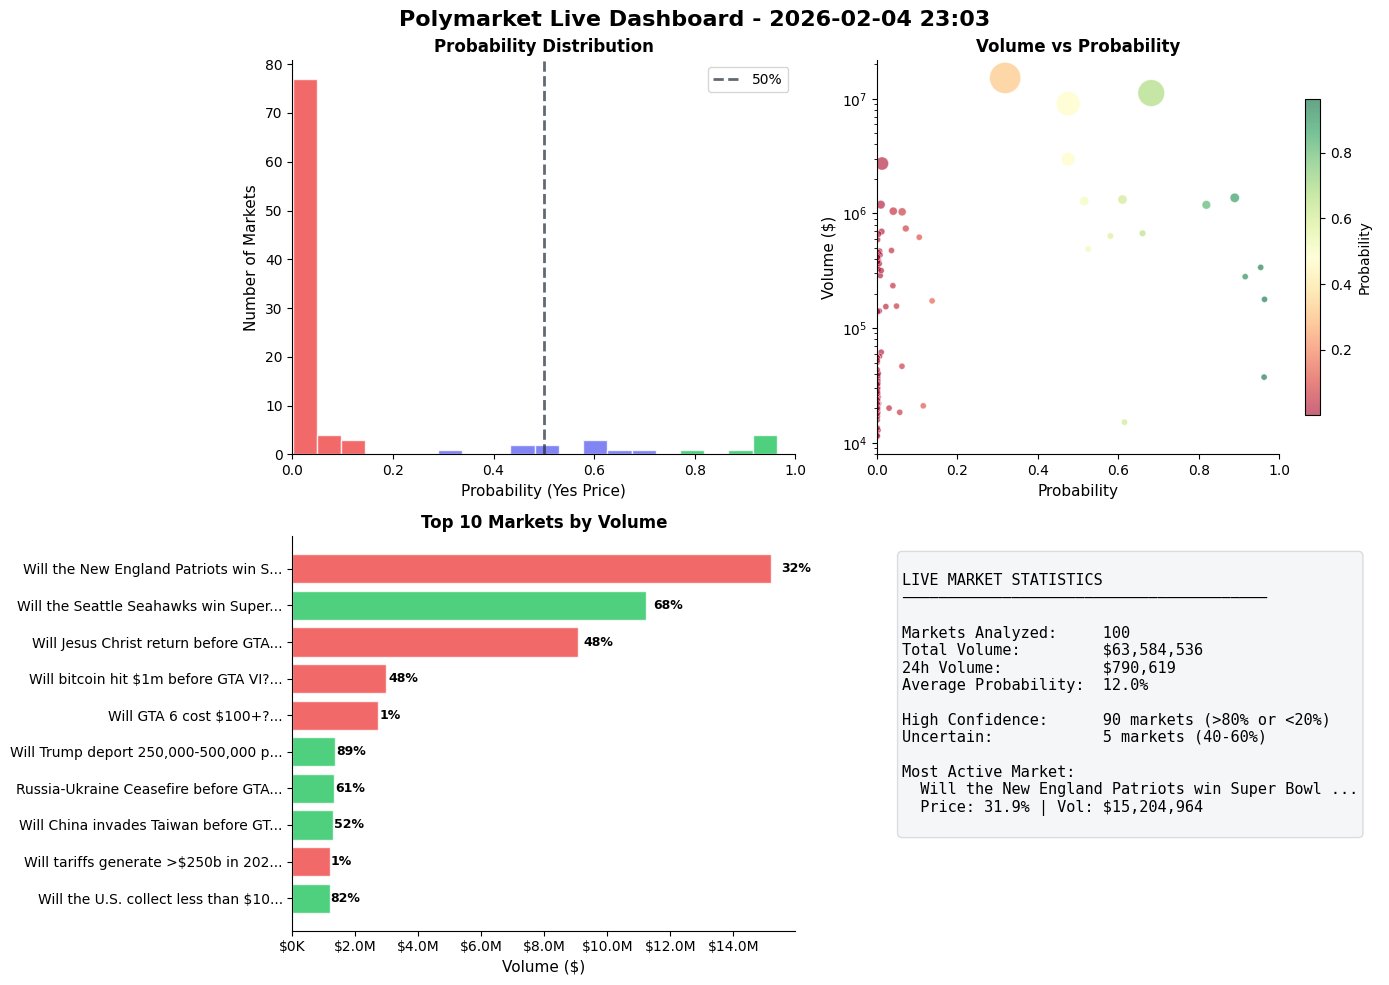

In [ ]:
# Create dashboard with live data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Polymarket Live Dashboard - {datetime.now().strftime("%Y-%m-%d %H:%M")}',
             fontsize=16, fontweight='bold')

# Filter to markets with meaningful data
plot_df = df[df['volume'] > 0].copy()

# 1. Probability Distribution (Top Left)
ax1 = axes[0, 0]
prices = plot_df['yes_price'].dropna()
n, bins, patches = ax1.hist(prices, bins=20, edgecolor='white', alpha=0.8)
for i, patch in enumerate(patches):
    mid = (bins[i] + bins[i+1]) / 2
    if mid < 0.3:
        patch.set_facecolor('#ef4444')  # red - unlikely
    elif mid > 0.7:
        patch.set_facecolor('#22c55e')  # green - likely
    else:
        patch.set_facecolor('#6366f1')  # purple - uncertain
ax1.axvline(0.5, color='#1f2937', linestyle='--', linewidth=2, alpha=0.7, label='50%')
ax1.set_xlabel('Probability (Yes Price)', fontsize=11)
ax1.set_ylabel('Number of Markets', fontsize=11)
ax1.set_title('Probability Distribution', fontsize=12, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.legend()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 2. Volume vs Probability Scatter (Top Right)
ax2 = axes[0, 1]
volumes = plot_df['volume'].fillna(1)
sizes = np.clip(volumes / volumes.max() * 500, 20, 500)
scatter = ax2.scatter(
    plot_df['yes_price'],
    volumes,
    s=sizes,
    c=plot_df['yes_price'],
    cmap='RdYlGn',
    alpha=0.6,
    edgecolors='white',
    linewidths=0.5
)
ax2.set_xlabel('Probability', fontsize=11)
ax2.set_ylabel('Volume ($)', fontsize=11)
ax2.set_title('Volume vs Probability', fontsize=12, fontweight='bold')
ax2.set_yscale('log')
ax2.set_xlim(0, 1)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
cbar = plt.colorbar(scatter, ax=ax2, shrink=0.8)
cbar.set_label('Probability', fontsize=10)

# 3. Top 10 Markets by Volume (Bottom Left)
ax3 = axes[1, 0]
top10 = plot_df.nlargest(10, 'volume')[['question', 'volume', 'yes_price']].copy()
top10['short_q'] = top10['question'].str[:35] + '...'
top10 = top10.iloc[::-1]
bar_colors = ['#22c55e' if p > 0.5 else '#ef4444' for p in top10['yes_price']]
bars = ax3.barh(top10['short_q'], top10['volume'], color=bar_colors, alpha=0.8, edgecolor='white')
ax3.set_xlabel('Volume ($)', fontsize=11)
ax3.set_title('Top 10 Markets by Volume', fontsize=12, fontweight='bold')
ax3.xaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'
))
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
for bar, prob in zip(bars, top10['yes_price']):
    ax3.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height()/2,
             f'{prob:.0%}', va='center', fontsize=9, fontweight='bold')

# 4. Summary Stats (Bottom Right)
ax4 = axes[1, 1]
ax4.axis('off')

total_vol = plot_df['volume'].sum()
vol_24h = plot_df['volume_24h'].sum()
avg_price = plot_df['yes_price'].mean()
high_conf = len(plot_df[(plot_df['yes_price'] > 0.8) | (plot_df['yes_price'] < 0.2)])
uncertain = len(plot_df[(plot_df['yes_price'] > 0.4) & (plot_df['yes_price'] < 0.6)])
top_market = plot_df.loc[plot_df['volume'].idxmax()]

stats_text = f"""
LIVE MARKET STATISTICS
{'─' * 40}

Markets Analyzed:     {len(plot_df):,}
Total Volume:         ${total_vol:,.0f}
24h Volume:           ${vol_24h:,.0f}
Average Probability:  {avg_price:.1%}

High Confidence:      {high_conf} markets (>80% or <20%)
Uncertain:            {uncertain} markets (40-60%)

Most Active Market:
  {top_market['question'][:45]}...
  Price: {top_market['yes_price']:.1%} | Vol: ${top_market['volume']:,.0f}
"""

ax4.text(0.05, 0.95, stats_text, transform=ax4.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f3f4f6', edgecolor='#d1d5db', alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

---

## 7. Order Book Deep Dive

The **order book** shows all pending buy (bid) and sell (ask) orders.

This is where you see the actual liquidity - how much you can trade and at what prices.

In [ ]:
# Find a high-volume market with an orderbook
markets_with_tokens = df[df['yes_token'].notna()].sort_values('volume', ascending=False)

orderbook_found = False
for _, market in markets_with_tokens.head(10).iterrows():
    token_id = market['yes_token']

    try:
        orderbook = pm.fetch_orderbook(token_id)

        if len(orderbook) > 0:
            print("ORDER BOOK ANALYSIS")
            print("=" * 70)
            print(f"Market: {market['question'][:65]}...")
            print(f"Current Price: {market['yes_price']:.1%}")
            print(f"Total Volume: ${market['volume']:,.0f}")
            print()

            bids = orderbook[orderbook['side'] == 'bid'].sort_values('price', ascending=False)
            asks = orderbook[orderbook['side'] == 'ask'].sort_values('price', ascending=True)

            print(f"BIDS (Buy Orders) - {len(bids)} levels")
            print("People wanting to BUY at these prices:")
            if len(bids) > 0:
                bid_display = bids[['price', 'size']].head(5).copy()
                bid_display['price'] = bid_display['price'].apply(lambda x: f"${x:.4f}")
                bid_display['size'] = bid_display['size'].apply(lambda x: f"{x:,.2f} shares")
                print(bid_display.to_string(index=False))

            print(f"\nASKS (Sell Orders) - {len(asks)} levels")
            print("People wanting to SELL at these prices:")
            if len(asks) > 0:
                ask_display = asks[['price', 'size']].head(5).copy()
                ask_display['price'] = ask_display['price'].apply(lambda x: f"${x:.4f}")
                ask_display['size'] = ask_display['size'].apply(lambda x: f"{x:,.2f} shares")
                print(ask_display.to_string(index=False))

            if len(bids) > 0 and len(asks) > 0:
                best_bid = bids['price'].max()
                best_ask = asks['price'].min()
                spread = best_ask - best_bid
                total_bid_size = bids['size'].sum()
                total_ask_size = asks['size'].sum()

                print(f"\n{'─' * 70}")
                print(f"SPREAD ANALYSIS")
                print(f"  Best Bid (highest buy):  ${best_bid:.4f}")
                print(f"  Best Ask (lowest sell):  ${best_ask:.4f}")
                print(f"  Spread:                  ${spread:.4f} ({spread*100:.2f}%)")
                print(f"\n  Total Bid Liquidity:     {total_bid_size:,.0f} shares")
                print(f"  Total Ask Liquidity:     {total_ask_size:,.0f} shares")

            orderbook_found = True
            break
    except Exception as e:
        continue

if not orderbook_found:
    print("Could not find an active orderbook. Markets may be illiquid.")

ORDER BOOK ANALYSIS
Market: Will the New England Patriots win Super Bowl 2026?...
Current Price: 31.9%
Total Volume: $15,204,964

BIDS (Buy Orders) - 86 levels
People wanting to BUY at these prices:
  price             size
$0.3180    900.00 shares
$0.3170  6,030.65 shares
$0.3160 27,394.72 shares
$0.3150     12.00 shares
$0.3130 12,260.02 shares

ASKS (Sell Orders) - 123 levels
People wanting to SELL at these prices:
  price             size
$0.3190 29,364.25 shares
$0.3200 67,414.25 shares
$0.3210  8,448.31 shares
$0.3220 17,410.00 shares
$0.3230  2,140.00 shares

──────────────────────────────────────────────────────────────────────
SPREAD ANALYSIS
  Best Bid (highest buy):  $0.3180
  Best Ask (lowest sell):  $0.3190
  Spread:                  $0.0010 (0.10%)

  Total Bid Liquidity:     5,253,775 shares
  Total Ask Liquidity:     9,307,596 shares


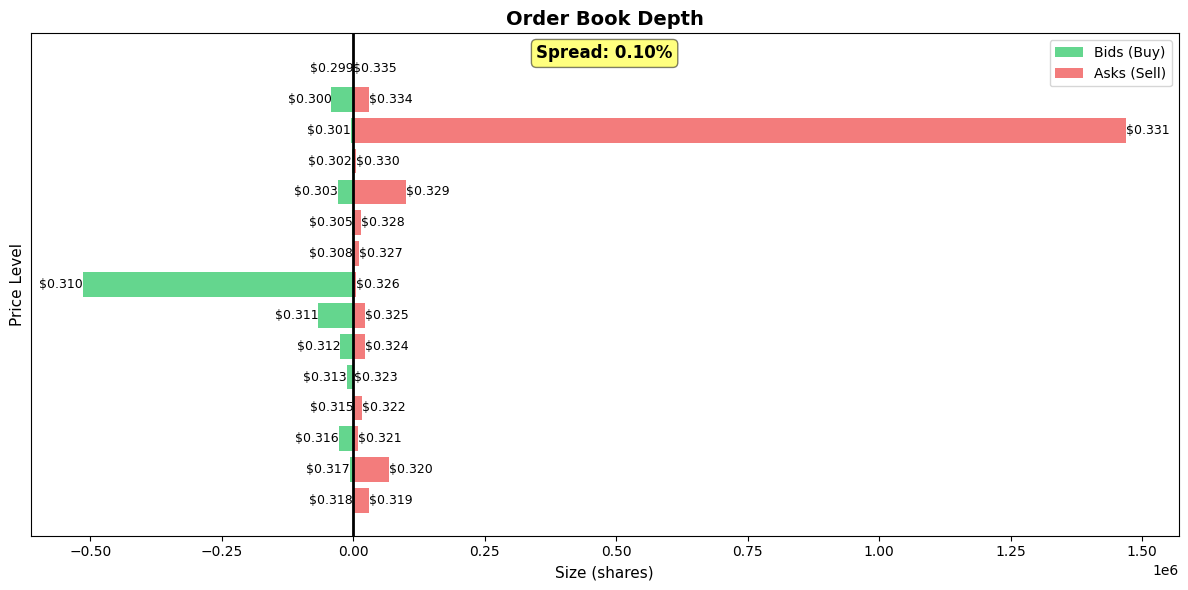

In [ ]:
# Visualize the orderbook if we found one
if orderbook_found and len(orderbook) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))

    bids = orderbook[orderbook['side'] == 'bid'].sort_values('price', ascending=False).head(15)
    asks = orderbook[orderbook['side'] == 'ask'].sort_values('price', ascending=True).head(15)

    # Plot bids (green, left side)
    ax.barh(range(len(bids)), -bids['size'].values, color='#22c55e', alpha=0.7, label='Bids (Buy)')

    # Plot asks (red, right side)
    ax.barh(range(len(asks)), asks['size'].values, color='#ef4444', alpha=0.7, label='Asks (Sell)')

    # Add price labels
    for i, (_, row) in enumerate(bids.iterrows()):
        ax.text(-row['size']-5, i, f"${row['price']:.3f}", va='center', ha='right', fontsize=9)
    for i, (_, row) in enumerate(asks.iterrows()):
        ax.text(row['size']+5, i, f"${row['price']:.3f}", va='center', ha='left', fontsize=9)

    ax.axvline(0, color='black', linewidth=2)
    ax.set_xlabel('Size (shares)', fontsize=11)
    ax.set_ylabel('Price Level', fontsize=11)
    ax.set_title('Order Book Depth', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    ax.set_yticks([])

    # Add spread annotation
    if len(bids) > 0 and len(asks) > 0:
        spread = asks['price'].min() - bids['price'].max()
        ax.text(0.5, 0.95, f"Spread: {spread*100:.2f}%", transform=ax.transAxes,
                ha='center', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

    plt.tight_layout()
    plt.show()

---

## 8. Sports Markets (NBA Example)

Sports markets are organized under **events**. An event contains multiple related markets.

For example, "2026 NBA Champion" is an event with 30 markets (one per team).

In [ ]:
# Fetch all open events
response = requests.get(
    "https://gamma-api.polymarket.com/events",
    params={"limit": 200, "closed": "false"}
)
events = response.json()

# Filter for NBA
nba_events = [e for e in events if "nba" in e.get("slug", "").lower()]

print(f"NBA EVENTS ON POLYMARKET")
print("=" * 80)
print(f"Found {len(nba_events)} NBA events\n")

for event in nba_events:
    title = event.get("title", "N/A")
    markets = event.get("markets", [])
    total_volume = sum(float(m.get("volume", 0)) for m in markets)

    print(f"📊 {title}")
    print(f"   Markets: {len(markets)} | Total Volume: ${total_volume:,.0f}")

    # Show top 3 markets by volume
    if markets:
        sorted_markets = sorted(markets, key=lambda x: float(x.get("volume", 0)), reverse=True)
        for m in sorted_markets[:3]:
            q = m.get('question', 'N/A')[:55]
            v = float(m.get('volume', 0))

            # Parse price
            prices = m.get('outcomePrices', '[]')
            if isinstance(prices, str):
                try:
                    prices = json.loads(prices)
                except:
                    prices = [0]
            p = float(prices[0]) if prices else 0

            print(f"      {p:>5.1%} | ${v:>12,.0f} | {q}...")
    print()

NBA EVENTS ON POLYMARKET
Found 5 NBA events

📊 2026 NBA Champion
   Markets: 30 | Total Volume: $229,343,624
       0.1% | $  30,180,060 | Will the Indiana Pacers win the 2026 NBA Finals?...
       0.2% | $  29,929,233 | Will the Memphis Grizzlies win the 2026 NBA Finals?...
       0.2% | $  17,512,216 | Will the Chicago Bulls win the 2026 NBA Finals?...

📊 NBA Rookie of the Year 
   Markets: 28 | Total Volume: $563,588
      85.0% | $      77,164 | Will Cooper Flagg win the 2025–26 NBA Rookie of the Yea...
       0.1% | $      57,854 | Will Dylan Harper win the 2025–26 NBA Rookie of the Yea...
      13.0% | $      49,760 | Will Kon Knueppel win the 2025–26 NBA Rookie of the Yea...

📊 NBA MVP 
   Markets: 33 | Total Volume: $20,243,798
       0.1% | $   4,091,154 | Will Trae Young win the 2025–2026 NBA MVP?...
       0.1% | $   2,178,235 | Will Ja Morant win the 2025–2026 NBA MVP?...
       8.8% | $   2,031,757 | Will Luka Doncic win the 2025–2026 NBA MVP?...

📊 NBA Eastern Conference 

NBA CHAMPIONSHIP ODDS
Event: 2026 NBA Champion

TOP CONTENDERS (by market probability):
----------------------------------------------------------------------
Oklahoma City Thunder           38.5% ███████████████████
Denver Nuggets                  11.5% █████
Cleveland Cavaliers              5.8% ██
Detroit Pistons                  5.8% ██
Boston Celtics                   5.5% ██
New York Knicks                  5.5% ██
Minnesota Timberwolves           5.1% ██
San Antonio Spurs                4.5% ██
Houston Rockets                  4.5% ██
Los Angeles Lakers               2.1% █


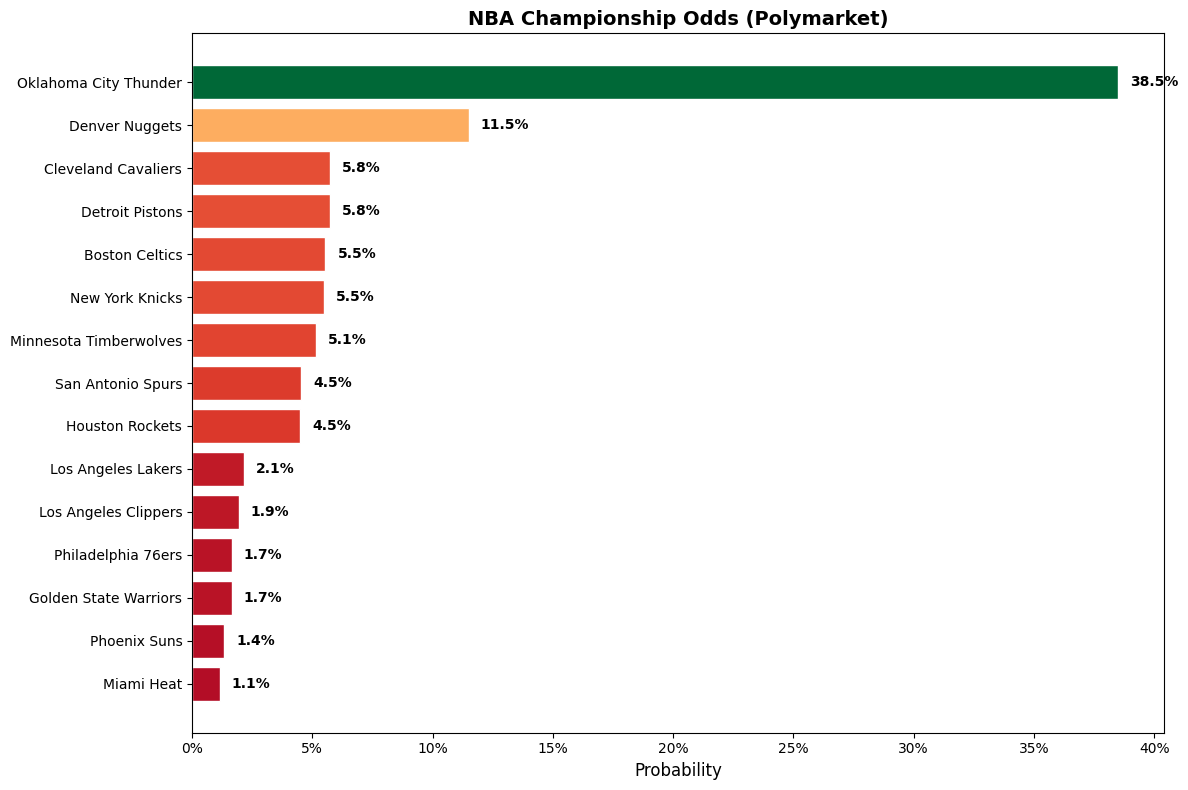

In [ ]:
# Deep dive into NBA Championship odds
championship = next((e for e in nba_events if "champion" in e.get("title", "").lower()), None)

if championship:
    print(f"NBA CHAMPIONSHIP ODDS")
    print("=" * 70)
    print(f"Event: {championship.get('title')}")
    print()

    markets = championship.get("markets", [])

    # Parse all teams
    teams = []
    for m in markets:
        q = m.get('question', '')
        # Extract team name
        if 'Will the' in q and 'win' in q.lower():
            team = q.replace('Will the ', '').split(' win')[0]
        else:
            team = q[:30]

        prices = m.get('outcomePrices', '[]')
        if isinstance(prices, str):
            try:
                prices = json.loads(prices)
            except:
                prices = [0]
        prob = float(prices[0]) if prices else 0
        vol = float(m.get('volume', 0))

        teams.append({'team': team, 'probability': prob, 'volume': vol})

    # Sort by probability
    teams_df = pd.DataFrame(teams).sort_values('probability', ascending=False)

    # Show top contenders
    print("TOP CONTENDERS (by market probability):")
    print("-" * 70)
    for i, row in teams_df.head(10).iterrows():
        bar = "█" * int(row['probability'] * 50)
        print(f"{row['team']:30} {row['probability']:>6.1%} {bar}")

    # Visualize
    fig, ax = plt.subplots(figsize=(12, 8))
    top_teams = teams_df.head(15).iloc[::-1]
    colors = plt.cm.RdYlGn(top_teams['probability'].values / top_teams['probability'].max())
    ax.barh(top_teams['team'], top_teams['probability'], color=colors, edgecolor='white')
    ax.set_xlabel('Probability', fontsize=12)
    ax.set_title('NBA Championship Odds (Polymarket)', fontsize=14, fontweight='bold')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))

    for i, (_, row) in enumerate(top_teams.iterrows()):
        ax.text(row['probability'] + 0.005, i, f"{row['probability']:.1%}",
                va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No NBA Championship event found")

---

## 9. Summary

### What We Learned

| Concept | Key Takeaway |
|---------|-------------|
| **Prices = Probabilities** | A yes_price of 0.65 means 65% probability |
| **Volume = Confidence** | High volume markets have more reliable prices |
| **Order Books** | Show actual liquidity and trading costs |
| **Spreads** | The cost of trading (lower = better) |
| **Events** | Group related markets (e.g., all NBA teams) |

### API Endpoints

| Endpoint | URL | Use For |
|----------|-----|--------|
| Markets | `gamma-api.polymarket.com/markets` | Individual predictions |
| Events | `gamma-api.polymarket.com/events` | Grouped markets (sports) |
| Order Book | `clob.polymarket.com/book` | Liquidity data |

### Next Steps

1. Read `API_GUIDE.md` for detailed documentation
2. Try filtering for different topics (politics, crypto, sports)
3. Compare Polymarket prices to traditional betting odds
4. Build your own analysis!